In [48]:
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

img = cv2.imread("test_image.png", 0)

sobel_x = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=5)
sobel_y = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=5)

laplacian = cv2.Laplacian(img, cv2.CV_64F)

cv2.imshow("Sobel X", sobel_x)
cv2.imshow("Sobel Y", sobel_y)
cv2.imshow("Laplacian", laplacian)
cv2.waitKey(0)
cv2.destroyAllWindows()


In [49]:
hist = cv2.calcHist([img], [0], None, [256], [0, 256])

mean = np.mean(hist)
std_dev = np.std(hist)

threshold = 0.1

if std_dev < threshold:
    print("Gaussian Noise detected.")
    img_smoothed = cv2.GaussianBlur(img, (5, 5), 0)
else:
    print("Salt and Pepper Noise detected.")
    img_smoothed = cv2.medianBlur(img, 5)

cv2.imshow("Smoothed Image", img_smoothed)
cv2.waitKey(0)
cv2.destroyAllWindows()

Salt and Pepper Noise detected.


Accuracy on the original image: 0.5026416677792824
Accuracy on the smoothed image: 0.5026416677792824


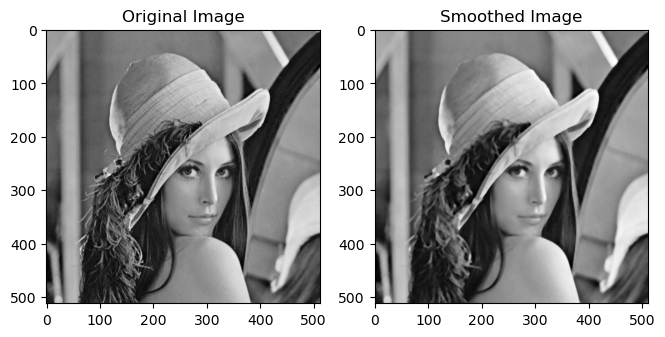

In [51]:
labels = np.random.randint(0, 2, size=img.shape)

def apply_logistic_regression(image, labels):
    features = image.reshape(-1, 1)
    
    labels = labels.reshape(-1)
    
    X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.2, random_state=42)
    
    model = LogisticRegression()
    
    model.fit(X_train, y_train)
    
    predictions = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, predictions)
    
    return accuracy

accuracy_original = apply_logistic_regression(img, labels)
print("Accuracy on the original image:", accuracy_original)

accuracy_smoothed = apply_logistic_regression(smoothed_image, labels)
print("Accuracy on the smoothed image:", accuracy_smoothed)

plt.figure(figsize=(12, 6))

plt.subplot(131)
plt.imshow(img, cmap='gray')
plt.title("Original Image")

plt.subplot(132)
plt.imshow(smoothed_image, cmap='gray')
plt.title("Smoothed Image")

plt.show()

In [58]:
sobel_x = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=5)
sobel_y = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=5)

gradient_magnitude = np.sqrt(sobel_x**2 + sobel_y**2)

threshold = 300

edge_map = (gradient_magnitude > threshold).astype(np.uint8)

cv2.imshow("Edge Map", edge_map * 255)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [60]:
labels = np.random.randint(0, 2, size=edge_map.shape)

features = edge_map.reshape(-1, 1)

labels = labels.reshape(-1)

X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.2, random_state=42)

model = LogisticRegression()

model.fit(X_train, y_train)

predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)
print("Accuracy on the edge map:", accuracy)

Accuracy on the edge map: 0.499399187472582


In [62]:
def apply_smoothing_filter(image):
    hist = cv2.calcHist([image], [0], None, [256], [0, 256])
    mean = np.mean(hist)
    std_dev = np.std(hist)
    
    threshold = 0.1  
    
    if std_dev < threshold:
        print("Gaussian Noise detected.")
        smoothed_image = cv2.GaussianBlur(image, (5, 5), 0)
    else:
        print("Salt and Pepper Noise detected.")
        smoothed_image = cv2.medianBlur(image, 5)
    
    return smoothed_image

smoothed_image = apply_smoothing_filter(img)

def apply_edge_detection(image, threshold):
    sobel_x = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=5)
    sobel_y = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=5)
    gradient_magnitude = np.sqrt(sobel_x**2 + sobel_y**2)
    edge_map = (gradient_magnitude > threshold).astype(np.uint8)
    return edge_map

edge_threshold = 50

edge_map = apply_edge_detection(smoothed_image, edge_threshold)

labels = np.random.randint(0, 2, size=edge_map.shape)

features = edge_map.reshape(-1, 1)

labels = labels.reshape(-1)

X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.2, random_state=42)

model = LogisticRegression()

model.fit(X_train, y_train)

predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)
print("Accuracy on the edge map:", accuracy)

Salt and Pepper Noise detected.
Accuracy on the edge map: 0.4988079116519484
